# Best Model Analysis & Poster-Ready Visualizations

Refines the best model and creates clean, impactful charts for the poster.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
Path('outputs/models').mkdir(parents=True, exist_ok=True)

master = pd.read_csv('data/processed/master_dataset.csv', index_col=0, parse_dates=True)
print(f' Loaded: {master.shape}')

✅ Loaded: (1370, 55)


## 1. Refined Feature Engineering

Adding features we missed in the first round.

In [9]:
df = master.copy()
price_col = 'retail_national' if 'retail_national' in df.columns else 'retail_gas_fred'
crude_col = 'wti_crude' if 'wti_crude' in df.columns else 'wti_crude_fred'

# --- Target ---
df['target'] = df[price_col].diff().shift(-1)

# --- Basic price features ---
df['retail_chg'] = df[price_col].diff()
df['retail_pct_chg'] = df[price_col].pct_change() * 100

# --- Lagged changes (1-4 weeks back) ---
for lag in [1, 2, 3, 4]:
    df[f'retail_chg_lag{lag}'] = df['retail_chg'].shift(lag)

# --- Crude oil features ---
if crude_col in df.columns:
    df['crude_chg'] = df[crude_col].diff()
    df['crude_pct_chg'] = df[crude_col].pct_change() * 100
    df['crude_per_gallon'] = df[crude_col] / 42.0
    df['crude_retail_spread'] = df[price_col] - df['crude_per_gallon']
    for lag in [1, 2, 3, 4]:
        df[f'crude_chg_lag{lag}'] = df['crude_chg'].shift(lag)

# --- Spot/wholesale ---
spot_col = None
for c in ['spot_gasoline', 'spot_gas_nyh', 'spot_gas_gulf']:
    if c in df.columns:
        spot_col = c
        df['spot_chg'] = df[c].diff()
        if 'crude_per_gallon' in df.columns:
            df['crack_spread'] = df[c] - df['crude_per_gallon']
            df['crack_spread_chg'] = df['crack_spread'].diff()
        break

# --- Moving averages & deviations ---
df['retail_ma4'] = df[price_col].rolling(4).mean()
df['retail_ma12'] = df[price_col].rolling(12).mean()
df['retail_ma4_diff'] = df[price_col] - df['retail_ma4']
df['retail_ma12_diff'] = df[price_col] - df['retail_ma12']
df['retail_volatility'] = df['retail_chg'].rolling(12).std()

# --- NEW: 52-week high/low ratios ---
df['retail_52w_high'] = df[price_col].rolling(52).max()
df['retail_52w_low'] = df[price_col].rolling(52).min()
df['retail_52w_position'] = (df[price_col] - df['retail_52w_low']) / (df['retail_52w_high'] - df['retail_52w_low'] + 0.001)

# --- NEW: Futures spread (contango/backwardation signal) ---
if 'crude_futures_1m' in df.columns and 'crude_futures_2m' in df.columns:
    df['futures_spread'] = df['crude_futures_2m'] - df['crude_futures_1m']

# --- NEW: Momentum indicators ---
df['retail_momentum_4w'] = df[price_col].diff(4)
df['retail_momentum_12w'] = df[price_col].diff(12)
if crude_col in df.columns:
    df['crude_momentum_4w'] = df[crude_col].diff(4)

# --- NEW: Rate of change acceleration ---
df['retail_chg_acceleration'] = df['retail_chg'].diff()  # is price change speeding up or slowing?

# --- Supply features ---
if 'gasoline_stocks' in df.columns:
    df['stocks_chg'] = df['gasoline_stocks'].diff()
    df['stocks_pct_chg'] = df['gasoline_stocks'].pct_change() * 100
    df['stocks_ma4_diff'] = df['gasoline_stocks'] - df['gasoline_stocks'].rolling(4).mean()

# --- Seasonal ---
df['month'] = df.index.month
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['is_summer_blend'] = df['month'].between(3, 9).astype(int)

print(f'Total features created: {df.shape[1]}')

Total features created: 84


In [10]:
# Select all candidate features
exclude_cols = ['target', price_col, 'target_next_week_chg', 'target_direction', 'price_direction']
all_feature_cols = [c for c in df.columns if c not in exclude_cols 
                    and df[c].dtype in ['float64', 'int64', 'int32']
                    and df[c].notna().mean() > 0.7]  # at least 70% non-null

print(f'Candidate features: {len(all_feature_cols)}')

# Prepare modeling data
model_df = df[all_feature_cols + ['target']].dropna()
print(f'Clean rows: {len(model_df)}')

# Split
TEST_WEEKS = 52
train = model_df.iloc[:-TEST_WEEKS]
test = model_df.iloc[-TEST_WEEKS:]

X_train = train[all_feature_cols]
y_train = train['target']
X_test = test[all_feature_cols]
y_test = test['target']

print(f'Train: {len(train)} weeks | Test: {len(test)} weeks')
print(f'Features: {len(all_feature_cols)}')

Candidate features: 75
Clean rows: 962
Train: 910 weeks | Test: 52 weeks
Features: 75


## 2. Optimized Lasso with Cross-Validated Alpha

In [11]:
# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Use LassoCV to find optimal regularization strength
lasso_cv = LassoCV(alphas=np.logspace(-5, -1, 100), cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_s, y_train)

print(f'Optimal alpha: {lasso_cv.alpha_:.6f}')
print(f'Non-zero features: {np.sum(lasso_cv.coef_ != 0)}/{len(all_feature_cols)}')

# Predictions
y_pred = lasso_cv.predict(X_test_s)

# Naive baseline
y_naive = np.zeros(len(y_test))

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
dir_acc = ((y_test > 0).astype(int) == (y_pred > 0).astype(int)).mean() * 100

naive_mae = mean_absolute_error(y_test, y_naive)
naive_dir = ((y_test > 0).astype(int) == (y_naive > 0).astype(int)).mean() * 100
improvement = ((naive_mae - mae) / naive_mae) * 100

print(f'\n{"=" * 50}')
print(f'OPTIMIZED LASSO RESULTS')
print(f'{"=" * 50}')
print(f'MAE:     ${mae:.4f}/gal  (naive: ${naive_mae:.4f})')
print(f'RMSE:    ${rmse:.4f}/gal')
print(f'R²:      {r2:.4f}')
print(f'Dir Acc: {dir_acc:.1f}%  (naive: {naive_dir:.1f}%)')
print(f'Improvement over naive: {improvement:.1f}%')

# Which features survived Lasso?
kept_features = pd.Series(lasso_cv.coef_, index=all_feature_cols)
kept = kept_features[kept_features != 0].sort_values(key=abs, ascending=False)
dropped = kept_features[kept_features == 0]

print(f'\nFeatures KEPT by Lasso ({len(kept)}):')
for feat, coef in kept.items():
    direction = '↑' if coef > 0 else '↓'
    print(f'  {direction} {feat:<35} coef: {coef:+.6f}')
print(f'\nFeatures DROPPED ({len(dropped)}): {dropped.index.tolist()}')

Optimal alpha: 0.001668
Non-zero features: 20/75

OPTIMIZED LASSO RESULTS
MAE:     $0.0306/gal  (naive: $0.0458)
RMSE:    $0.0418/gal
R²:      0.4535
Dir Acc: 76.9%  (naive: 57.7%)
Improvement over naive: 33.2%

Features KEPT by Lasso (20):
  ↑ retail_national_chg                 coef: +0.014482
  ↑ wti_crude_fred_chg                  coef: +0.014464
  ↓ gasoline_stocks_pct_chg             coef: -0.008249
  ↑ retail_ma4_diff                     coef: +0.007542
  ↑ crack_spread_chg                    coef: +0.006862
  ↓ retail_volatility                   coef: -0.003873
  ↓ month                               coef: -0.002913
  ↓ crude_retail_spread                 coef: -0.002072
  ↓ quarter                             coef: -0.001801
  ↓ is_summer_blend                     coef: -0.001767
  ↓ retail_padd4_rocky                  coef: -0.001556
  ↑ crude_chg_lag1                      coef: +0.001256
  ↓ week_of_year                        coef: -0.001239
  ↑ gasoline_stocks            

---
## 3. Poster Chart 1: Prediction Results Dashboard

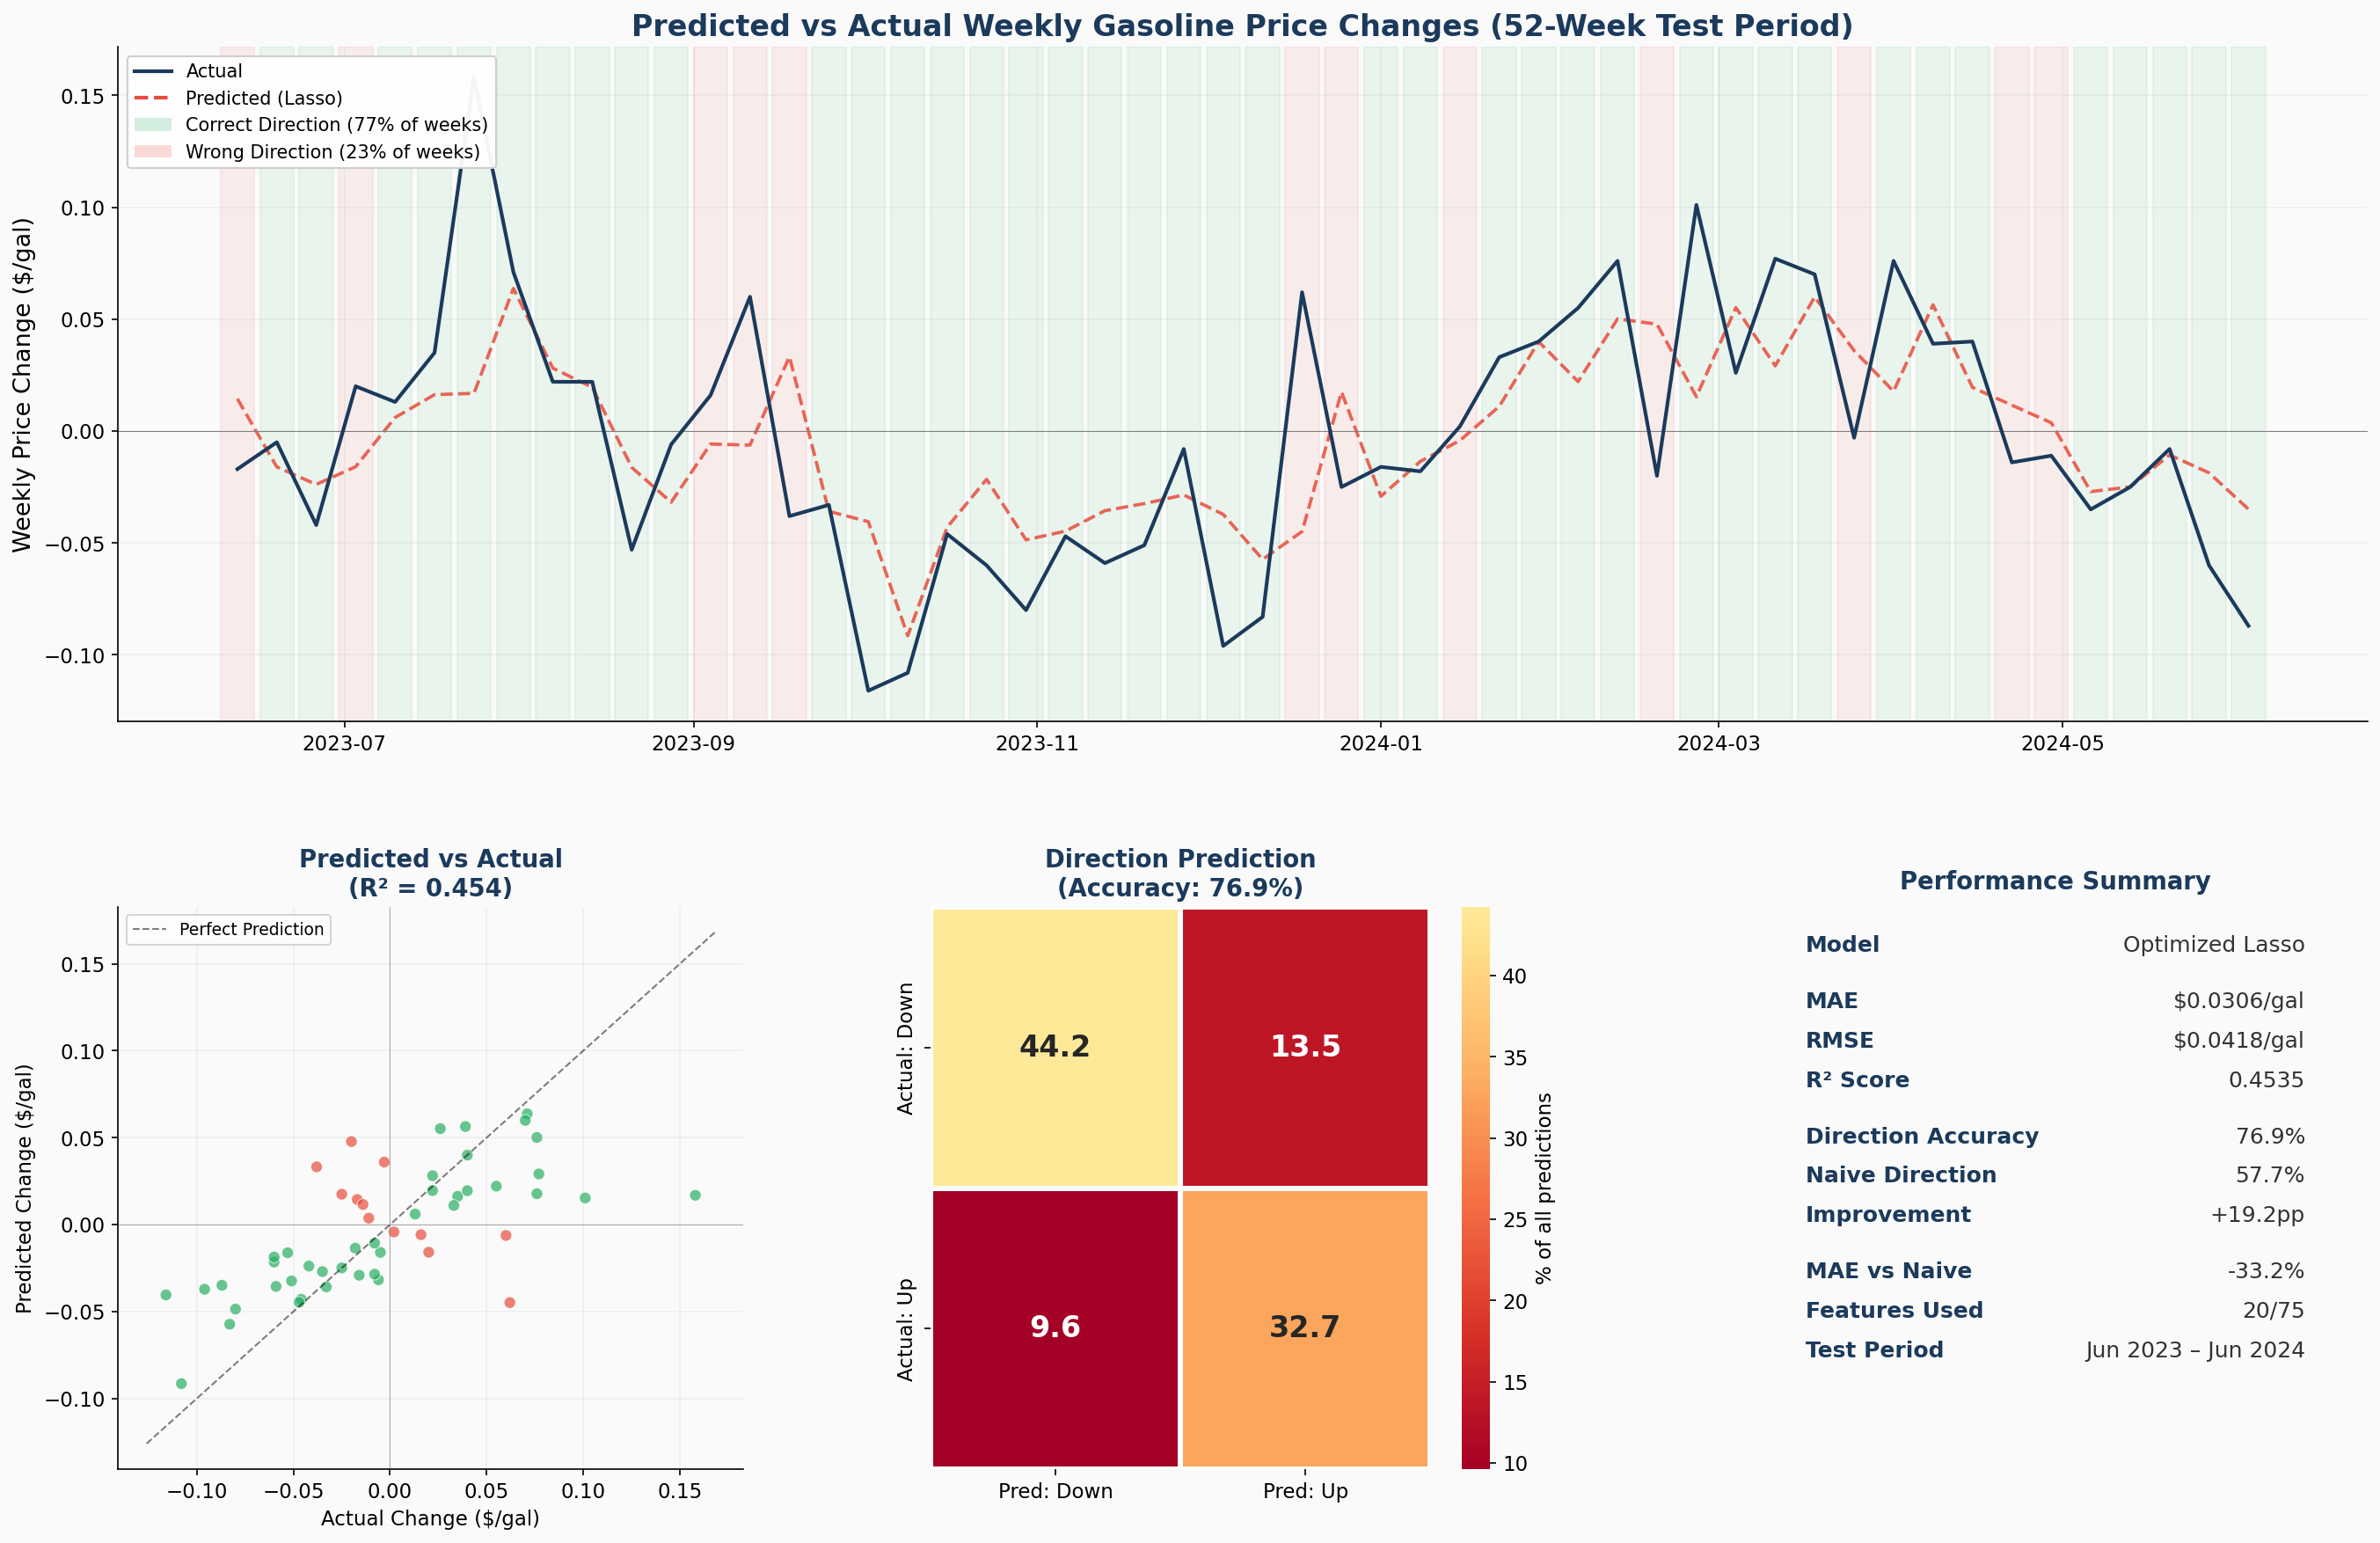

✅ Saved: outputs/models/prediction_dashboard.png


In [12]:
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#FAFAFA')

# Layout: 2 rows, top row = time series, bottom row = 3 panels
gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1], hspace=0.3, wspace=0.3)

# ============================================================
# TOP ROW: Actual vs Predicted (full width)
# ============================================================
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#FAFAFA')
ax1.grid(True, alpha=0.15)

# Actual
ax1.plot(y_test.index, y_test.values, color='#1B3A5C', linewidth=2, label='Actual Price Change', zorder=3)
# Predicted
ax1.plot(y_test.index, y_pred, color='#E74C3C', linewidth=1.8, linestyle='--', 
         label='Lasso Predicted', alpha=0.85, zorder=2)

# Shade correct vs incorrect predictions
correct = (y_test.values > 0) == (y_pred > 0)
for i in range(len(y_test)):
    if correct[i]:
        ax1.axvspan(y_test.index[i] - pd.Timedelta(days=3), 
                   y_test.index[i] + pd.Timedelta(days=3),
                   alpha=0.08, color='#27AE60', zorder=0)
    else:
        ax1.axvspan(y_test.index[i] - pd.Timedelta(days=3), 
                   y_test.index[i] + pd.Timedelta(days=3),
                   alpha=0.08, color='#E74C3C', zorder=0)

ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_ylabel('Weekly Price Change ($/gal)', fontsize=13)
ax1.set_title('Predicted vs Actual Weekly Gasoline Price Changes (52-Week Test Period)',
              fontsize=16, fontweight='bold', color='#1B3A5C')

# Custom legend
legend_elements = [
    plt.Line2D([0], [0], color='#1B3A5C', linewidth=2, label='Actual'),
    plt.Line2D([0], [0], color='#E74C3C', linewidth=2, linestyle='--', label='Predicted (Lasso)'),
    Patch(facecolor='#27AE60', alpha=0.2, label=f'Correct Direction ({dir_acc:.0f}% of weeks)'),
    Patch(facecolor='#E74C3C', alpha=0.2, label=f'Wrong Direction ({100-dir_acc:.0f}% of weeks)'),
]
ax1.legend(handles=legend_elements, fontsize=10, framealpha=0.95, loc='upper left')

# ============================================================
# BOTTOM LEFT: Scatter — Predicted vs Actual
# ============================================================
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#FAFAFA')
ax2.grid(True, alpha=0.15)

colors_scatter = ['#27AE60' if c else '#E74C3C' for c in correct]
ax2.scatter(y_test.values, y_pred, c=colors_scatter, s=40, alpha=0.7, edgecolors='white', linewidths=0.5)

# Perfect prediction line
lims = [min(y_test.min(), y_pred.min()) - 0.01, max(y_test.max(), y_pred.max()) + 0.01]
ax2.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='Perfect Prediction')
ax2.axhline(0, color='gray', linewidth=0.3)
ax2.axvline(0, color='gray', linewidth=0.3)

ax2.set_xlabel('Actual Change ($/gal)', fontsize=11)
ax2.set_ylabel('Predicted Change ($/gal)', fontsize=11)
ax2.set_title(f'Predicted vs Actual\n(R² = {r2:.3f})', fontweight='bold', color='#1B3A5C')
ax2.legend(fontsize=9)

# ============================================================
# BOTTOM CENTER: Direction Confusion Matrix
# ============================================================
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#FAFAFA')

actual_dir = (y_test > 0).astype(int)
pred_dir = (y_pred > 0).astype(int)
cm = confusion_matrix(actual_dir, pred_dir)

# Normalize to percentages
cm_pct = cm / cm.sum() * 100

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            xticklabels=['Pred: Down', 'Pred: Up'],
            yticklabels=['Actual: Down', 'Actual: Up'],
            ax=ax3, cbar_kws={'label': '% of all predictions'},
            linewidths=2, linecolor='white',
            annot_kws={'fontsize': 16, 'fontweight': 'bold'})

ax3.set_title(f'Direction Prediction\n(Accuracy: {dir_acc:.1f}%)', fontweight='bold', color='#1B3A5C')

# ============================================================
# BOTTOM RIGHT: Key Metrics Summary
# ============================================================
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('#FAFAFA')
ax4.axis('off')

metrics_text = [
    ('Model', 'Optimized Lasso'),
    ('', ''),
    ('MAE', f'${mae:.4f}/gal'),
    ('RMSE', f'${rmse:.4f}/gal'),
    ('R² Score', f'{r2:.4f}'),
    ('', ''),
    ('Direction Accuracy', f'{dir_acc:.1f}%'),
    ('Naive Direction', f'{naive_dir:.1f}%'),
    ('Improvement', f'+{dir_acc - naive_dir:.1f}pp'),
    ('', ''),
    ('MAE vs Naive', f'-{improvement:.1f}%'),
    ('Features Used', f'{len(kept)}/{len(all_feature_cols)}'),
    ('Test Period', f'{y_test.index[0].strftime("%b %Y")} – {y_test.index[-1].strftime("%b %Y")}'),
]

y_pos = 0.95
for label, value in metrics_text:
    if label == '' and value == '':
        y_pos -= 0.03
        continue
    ax4.text(0.1, y_pos, label, fontsize=12, fontweight='bold', color='#1B3A5C',
             transform=ax4.transAxes, va='top')
    ax4.text(0.9, y_pos, value, fontsize=12, color='#333333',
             transform=ax4.transAxes, va='top', ha='right')
    y_pos -= 0.07

ax4.set_title('Performance Summary', fontweight='bold', color='#1B3A5C', pad=10)

plt.savefig('outputs/models/prediction_dashboard.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(' Saved: outputs/models/prediction_dashboard.png')

## 4. Poster Chart 2: Feature Importance — What Drives the Prediction?

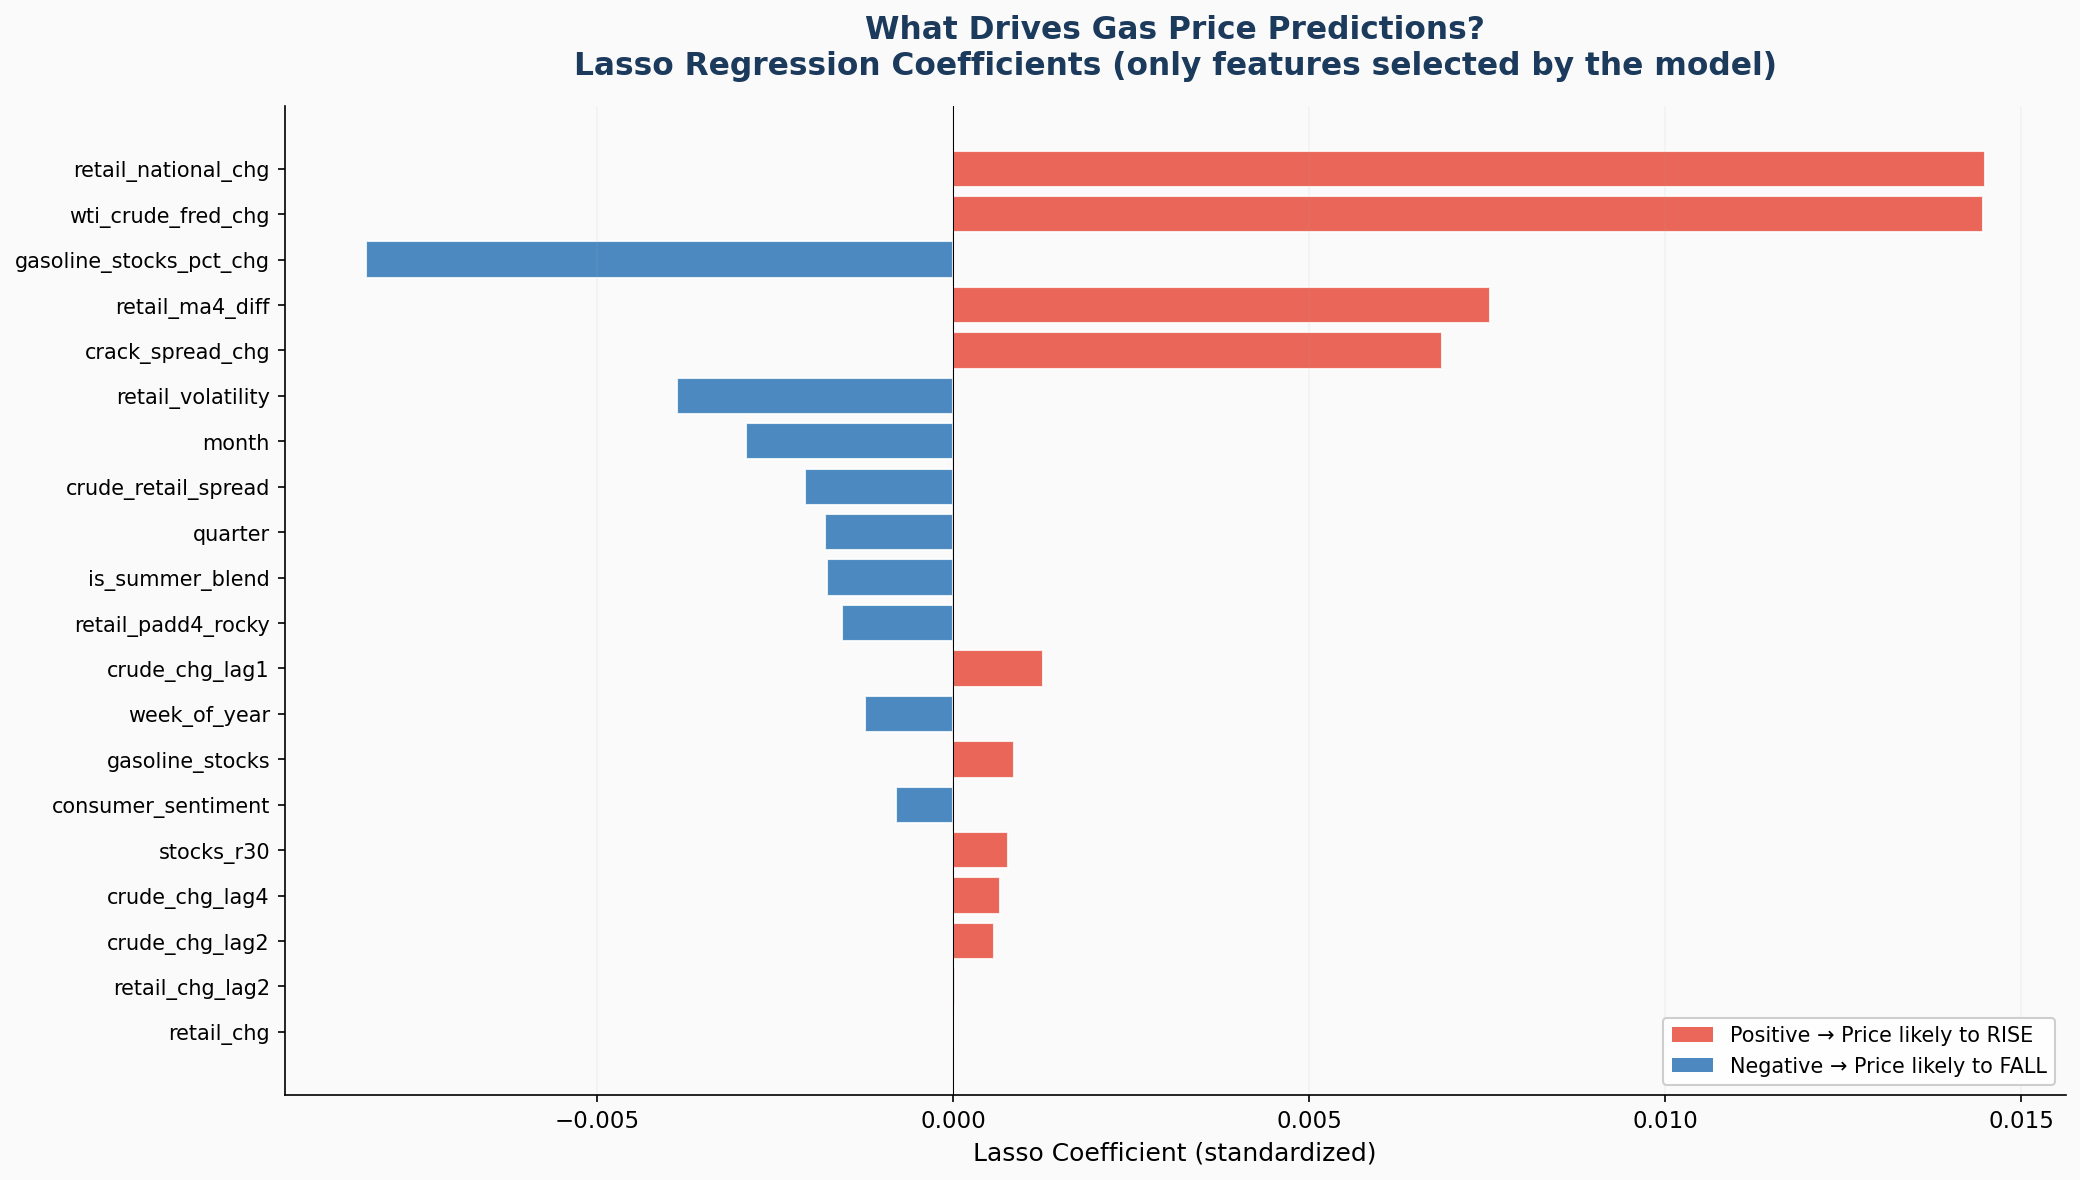

✅ Saved: outputs/models/feature_importance_lasso.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, alpha=0.1, axis='x')

# Only show kept features, sorted by absolute coefficient
kept_sorted = kept.sort_values(key=abs, ascending=True)  # ascending for horizontal bar

# Color by positive/negative coefficient
colors = ['#E74C3C' if v > 0 else '#2E75B6' for v in kept_sorted.values]

ax.barh(range(len(kept_sorted)), kept_sorted.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(kept_sorted)))
ax.set_yticklabels(kept_sorted.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_xlabel('Lasso Coefficient (standardized)', fontsize=12)
ax.set_title('What Drives Gas Price Predictions?\nLasso Regression Coefficients (only features selected by the model)',
             fontsize=15, fontweight='bold', color='#1B3A5C', pad=15)

# Legend
legend_elements = [
    Patch(facecolor='#E74C3C', alpha=0.85, label='Positive → Price likely to RISE'),
    Patch(facecolor='#2E75B6', alpha=0.85, label='Negative → Price likely to FALL'),
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.95, loc='lower right')

plt.tight_layout()
plt.savefig('outputs/models/feature_importance_lasso.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(' Saved: outputs/models/feature_importance_lasso.png')

## 5. Poster Chart 3: Model Comparison (All Models)

ALL MODELS COMPARISON:
                         Model    MAE   RMSE      R²  Dir. Acc (%)  MAPE (%)
               Optimized Lasso 0.0306 0.0418  0.4535       76.9231       NaN
                       XGBoost 0.0358 0.0468  0.3151       75.0000  125.8277
                 Random Forest 0.0360 0.0470  0.3081       78.8462  142.4317
Linear Regression (Crude Only) 0.0399 0.0518  0.1599       63.4615  104.8740
              Ridge Regression 0.0402 0.0491  0.2462       69.2308  174.2572
    Naive Baseline (No Change) 0.0458 0.0566 -0.0028       57.6923  100.0000
    Multiple Linear Regression 0.0460 0.0573 -0.0252       63.4615  204.0849


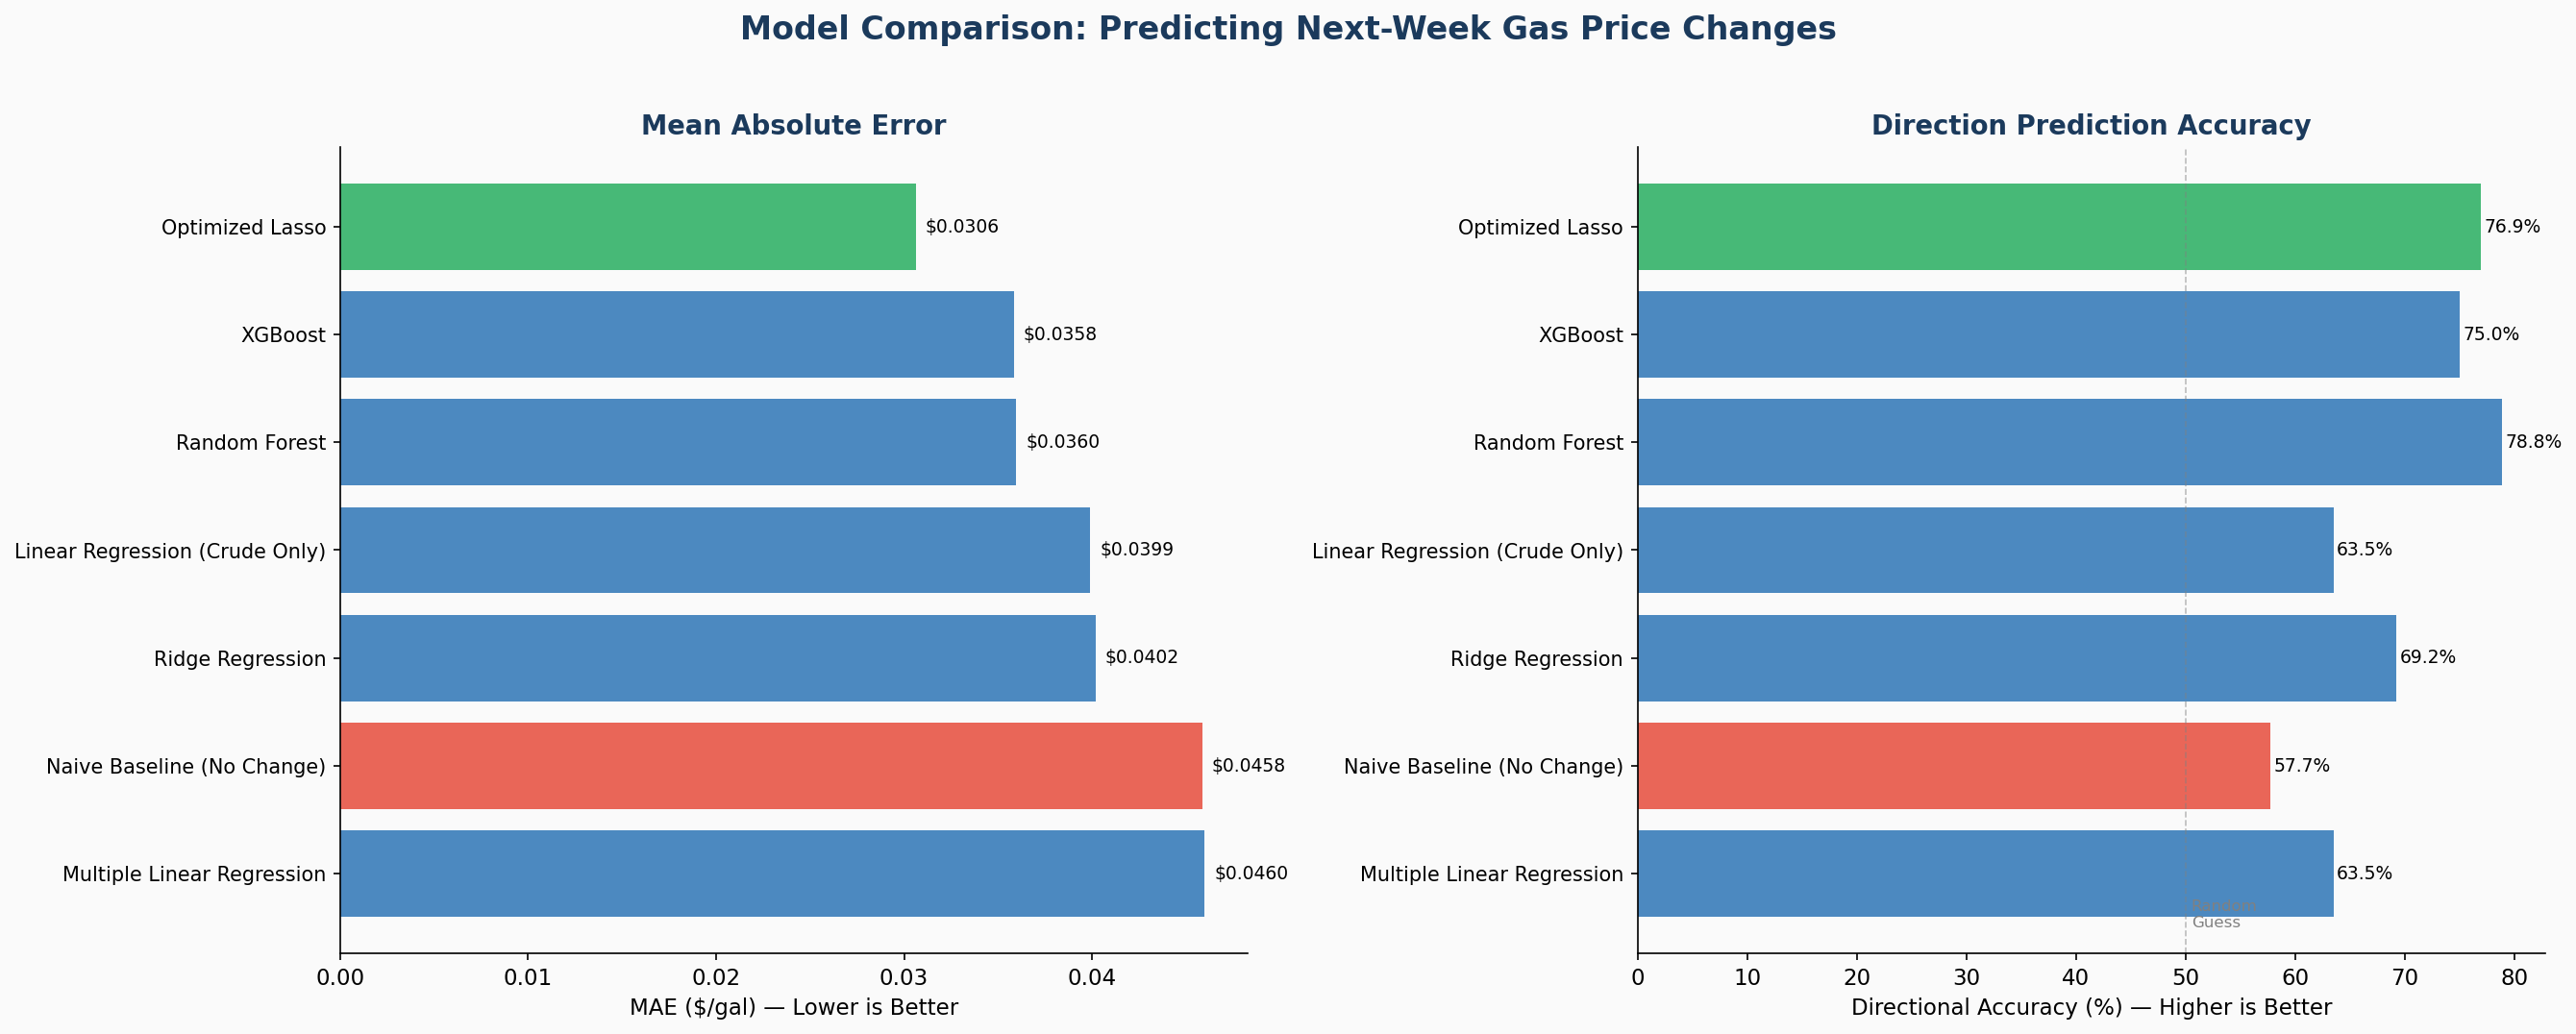

✅ Saved: outputs/models/model_comparison_final.png


In [14]:
# Load previous results and add optimized Lasso
prev_results_path = Path('outputs/models/model_comparison.csv')
if prev_results_path.exists():
    prev_results = pd.read_csv(prev_results_path)
else:
    # Create minimal comparison
    prev_results = pd.DataFrame([
        {'Model': 'Naive Baseline', 'MAE': naive_mae, 'RMSE': np.sqrt(mean_squared_error(y_test, y_naive)),
         'R²': r2_score(y_test, y_naive), 'Dir. Acc (%)': naive_dir},
    ])

# Add optimized lasso
new_row = pd.DataFrame([{
    'Model': 'Optimized Lasso', 'MAE': mae, 'RMSE': rmse,
    'R²': r2, 'Dir. Acc (%)': dir_acc
}])

# Remove old Lasso if exists
all_res = prev_results[~prev_results['Model'].str.contains('Lasso', case=False)]
all_res = pd.concat([all_res, new_row], ignore_index=True)
all_res = all_res.sort_values('MAE')

print('ALL MODELS COMPARISON:')
print(all_res.to_string(index=False, float_format='%.4f'))

# --- Chart ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Model Comparison: Predicting Next-Week Gas Price Changes',
             fontsize=16, fontweight='bold', color='#1B3A5C', y=1.02)

for ax in axes:
    ax.set_facecolor('#FAFAFA')

n = len(all_res)
bar_colors = []
for i, row in all_res.iterrows():
    if 'Optimized' in row['Model'] or 'Lasso' in row['Model']:
        bar_colors.append('#27AE60')  # best = green
    elif 'Naive' in row['Model']:
        bar_colors.append('#E74C3C')  # baseline = red
    else:
        bar_colors.append('#2E75B6')  # others = blue

# MAE
ax = axes[0]
bars = ax.barh(range(n), all_res['MAE'], color=bar_colors, alpha=0.85)
ax.set_yticks(range(n))
ax.set_yticklabels(all_res['Model'], fontsize=10)
ax.set_xlabel('MAE ($/gal) — Lower is Better')
ax.set_title('Mean Absolute Error', fontweight='bold', color='#1B3A5C')
for i, v in enumerate(all_res['MAE']):
    ax.text(v + 0.0005, i, f'${v:.4f}', va='center', fontsize=9)
ax.invert_yaxis()

# Directional Accuracy
ax = axes[1]
bars = ax.barh(range(n), all_res['Dir. Acc (%)'], color=bar_colors, alpha=0.85)
ax.set_yticks(range(n))
ax.set_yticklabels(all_res['Model'], fontsize=10)
ax.set_xlabel('Directional Accuracy (%) — Higher is Better')
ax.set_title('Direction Prediction Accuracy', fontweight='bold', color='#1B3A5C')
ax.axvline(50, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(50.5, n-0.5, 'Random\nGuess', fontsize=8, color='gray')
for i, v in enumerate(all_res['Dir. Acc (%)']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/models/model_comparison_final.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(' Saved: outputs/models/model_comparison_final.png')

## 6. Poster Chart 4: Actual vs Predicted Price Trajectory

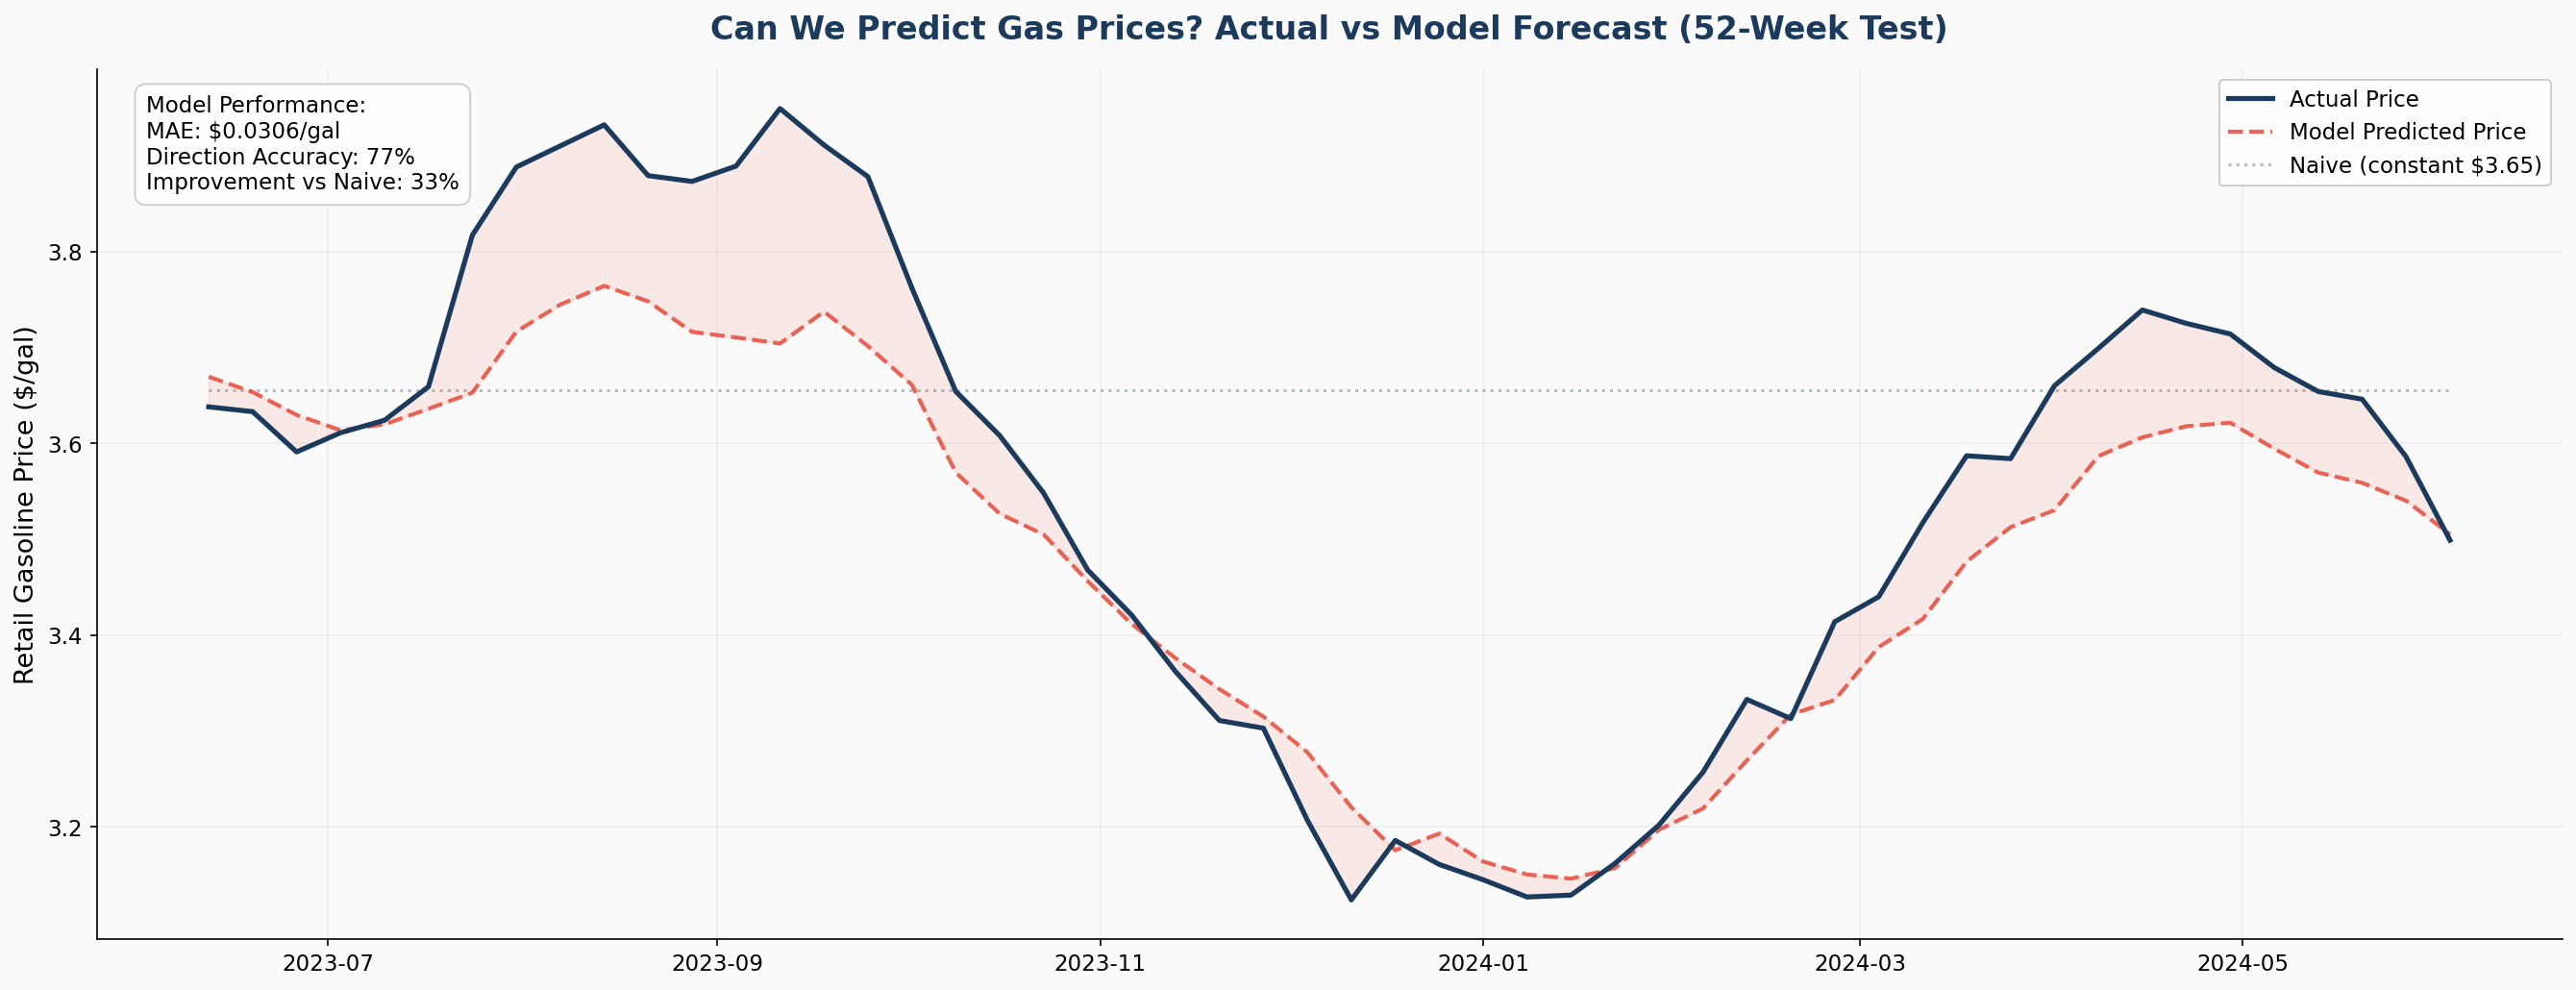

✅ Saved: outputs/models/price_trajectory.png


In [15]:
# Reconstruct actual and predicted PRICE LEVELS (not just changes)
# This shows the actual gas price trajectory vs what the model predicted

# Start from the last known price before test period
start_price = df[price_col].loc[:y_test.index[0]].iloc[-2]

actual_prices = start_price + np.cumsum(y_test.values)
predicted_prices = start_price + np.cumsum(y_pred)
naive_prices = np.full(len(y_test), start_price)  # naive = price never changes

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, alpha=0.15)

ax.plot(y_test.index, actual_prices, color='#1B3A5C', linewidth=2.5, label='Actual Price', zorder=3)
ax.plot(y_test.index, predicted_prices, color='#E74C3C', linewidth=2, linestyle='--',
        label='Model Predicted Price', alpha=0.85, zorder=2)
ax.plot(y_test.index, naive_prices, color='#95A5A6', linewidth=1.5, linestyle=':',
        label=f'Naive (constant ${start_price:.2f})', alpha=0.7, zorder=1)

# Fill between actual and predicted
ax.fill_between(y_test.index, actual_prices, predicted_prices, alpha=0.1, color='#E74C3C')

ax.set_ylabel('Retail Gasoline Price ($/gal)', fontsize=13)
ax.set_title('Can We Predict Gas Prices? Actual vs Model Forecast (52-Week Test)',
             fontsize=16, fontweight='bold', color='#1B3A5C', pad=15)

# Add metrics annotation
ax.annotate(
    f'Model Performance:\n'
    f'MAE: ${mae:.4f}/gal\n'
    f'Direction Accuracy: {dir_acc:.0f}%\n'
    f'Improvement vs Naive: {improvement:.0f}%',
    xy=(0.02, 0.97), xycoords='axes fraction',
    fontsize=11, va='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'),
)

ax.legend(fontsize=11, framealpha=0.95, loc='upper right')

plt.tight_layout()
plt.savefig('outputs/models/price_trajectory.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(' Saved: outputs/models/price_trajectory.png')

## 7. Summary

In [ ]:
print('=' * 60)
print('PREDICTION RESULTS — FINAL SUMMARY')
print('=' * 60)
print(f'''
Best Model: Optimized Lasso Regression
Alpha: {lasso_cv.alpha_:.6f} (cross-validated)

Performance:
  MAE:                ${mae:.4f}/gallon
  RMSE:               ${rmse:.4f}/gallon
  R² Score:           {r2:.4f}
  Direction Accuracy: {dir_acc:.1f}%
  
Compared to Naive Baseline:
  Naive MAE:          ${naive_mae:.4f}/gallon
  Naive Direction:    {naive_dir:.1f}%
  MAE Improvement:    {improvement:.1f}%
  Direction Gain:     +{dir_acc - naive_dir:.1f} percentage points

Features Selected: {len(kept)}/{len(all_feature_cols)}
Top Predictors:
''')

for i, (feat, coef) in enumerate(kept.head(5).items()):
    direction = 'RISES' if coef > 0 else 'FALLS'
    print(f'  {i+1}. {feat}: when this increases, gas price {direction}')

print(f'''
Interpretation:
  The model correctly predicts whether gas prices will go UP or
  DOWN in {dir_acc:.0f}% of weeks (vs {naive_dir:.0f}% for naive guess).
  
  Key insight: Recent price momentum (last 1-4 weeks of changes)
  and wholesale/spot market signals are the strongest predictors.
  Crude oil matters, but its effect is already partially priced
  into the retail-wholesale spread.

Files saved:
''')

for f in sorted(Path('outputs/models').glob('*.png')):
    print(f'  {f.name}')

print(f'\n All done!')

Using:
Retail gasoline: retail_national
Crude oil: wti_crude

Lag correlations:
   Lag (weeks)  Correlation
0            0     0.562955
1            1     0.396475
2            2     0.227756
3            3     0.175823
4            4     0.127318


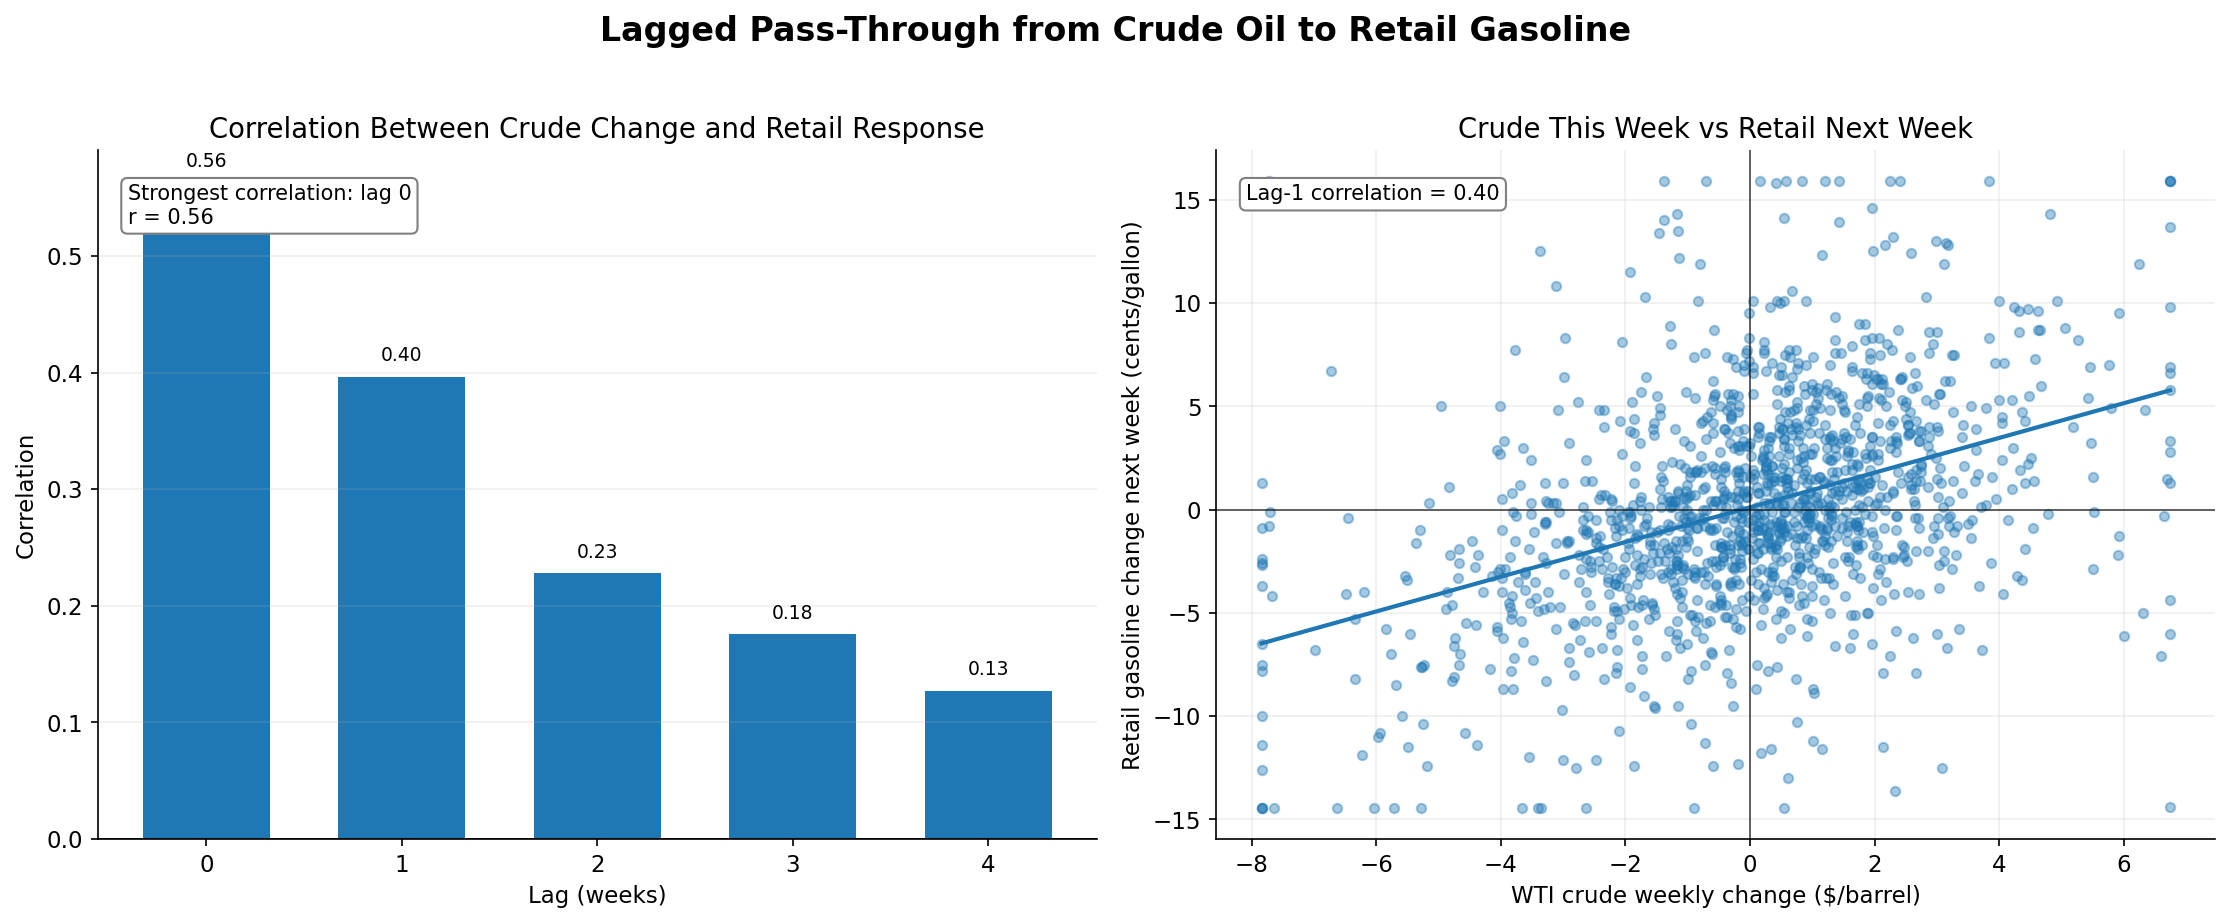

Saved: outputs/lagged_pass_through_clean.png


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
master = pd.read_csv("data/processed/master_dataset.csv", index_col=0, parse_dates=True)

price_col = "retail_national" if "retail_national" in master.columns else "retail_gas_fred"
crude_col = "wti_crude" if "wti_crude" in master.columns else "wti_crude_fred"

print("Using:")
print("Retail gasoline:", price_col)
print("Crude oil:", crude_col)

df = master[[price_col, crude_col]].copy().dropna()

# ------------------------------------------------------------
# Use level changes instead of percent changes
# crude: $/barrel weekly change
# retail: cents/gallon weekly change
# ------------------------------------------------------------
df["crude_change"] = df[crude_col].diff()                      # $/barrel
df["retail_change_cents"] = df[price_col].diff() * 100        # cents/gallon
df = df.dropna()

# ------------------------------------------------------------
# Winsorize helper to reduce extreme outlier distortion
# ------------------------------------------------------------
def winsorize_series(s, lower=0.01, upper=0.99):
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)

# ------------------------------------------------------------
# Correlation by lag
# lag = 0 => same week
# lag = 1 => crude this week vs retail next week
# ------------------------------------------------------------
max_lag = 4
lag_corrs = []

for lag in range(max_lag + 1):
    temp = pd.DataFrame({
        "crude_t": df["crude_change"],
        "retail_t_plus_lag": df["retail_change_cents"].shift(-lag)
    }).dropna()
    lag_corrs.append(temp["crude_t"].corr(temp["retail_t_plus_lag"]))

lag_df = pd.DataFrame({
    "Lag (weeks)": range(max_lag + 1),
    "Correlation": lag_corrs
})

print("\nLag correlations:")
print(lag_df)

# ------------------------------------------------------------
# Scatter for lag = 1
# ------------------------------------------------------------
scatter_df = pd.DataFrame({
    "Crude change this week ($/barrel)": df["crude_change"],
    "Retail change next week (cents/gal)": df["retail_change_cents"].shift(-1)
}).dropna()

# Winsorize for plotting only
scatter_df["x_plot"] = winsorize_series(scatter_df["Crude change this week ($/barrel)"])
scatter_df["y_plot"] = winsorize_series(scatter_df["Retail change next week (cents/gal)"])

x = scatter_df["x_plot"].values
y = scatter_df["y_plot"].values

# Best-fit line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b

corr_1 = scatter_df["Crude change this week ($/barrel)"].corr(
    scatter_df["Retail change next week (cents/gal)"]
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Lagged Pass-Through from Crude Oil to Retail Gasoline",
             fontsize=16, fontweight="bold", y=1.02)

# Left: lag bar chart
ax = axes[0]
bars = ax.bar(lag_df["Lag (weeks)"], lag_df["Correlation"], width=0.65)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(lag_df["Lag (weeks)"])
ax.set_xlabel("Lag (weeks)")
ax.set_ylabel("Correlation")
ax.set_title("Correlation Between Crude Change and Retail Response")
ax.grid(axis="y", alpha=0.2)

for bar, val in zip(bars, lag_df["Correlation"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}",
            ha="center", va="bottom", fontsize=9)

best_idx = lag_df["Correlation"].idxmax()
best_lag = lag_df.loc[best_idx, "Lag (weeks)"]
best_corr = lag_df.loc[best_idx, "Correlation"]

ax.text(0.03, 0.95,
        f"Strongest correlation: lag {best_lag}\nr = {best_corr:.2f}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

# Right: scatter
ax = axes[1]
ax.scatter(x, y, alpha=0.4, s=20)
ax.plot(x_line, y_line, linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.7)
ax.set_xlabel("WTI crude weekly change ($/barrel)")
ax.set_ylabel("Retail gasoline change next week (cents/gallon)")
ax.set_title("Crude This Week vs Retail Next Week")
ax.grid(alpha=0.2)

ax.text(0.03, 0.95,
        f"Lag-1 correlation = {corr_1:.2f}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
Path("outputs").mkdir(exist_ok=True)
fig.savefig("outputs/lagged_pass_through_clean.png", dpi=300, bbox_inches="tight")
print("Saved: outputs/lagged_pass_through_clean.png")